In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 1000)



In [2]:
data25 = pd.read_csv('data2025.csv')
# data24 = pd.read_csv('data2024.csv')

In [3]:
outs = [
    'field_out', 'force_out', 'grounded_into_double_play',
    'sac_fly', 'sac_bunt', 'fielders_choice', 'double_play',
    'fielders_choice_out',
    'sac_fly_double_play', 'triple_play', 'popup', 'strikeout', 'strikeout_double_play'
]

strikeout_code = ['strikeout', 'strikeout_double_play']

swing_code = ['foul_bunt', 'foul', 'hit_into_play', 'swinging_strike', 'foul_tip', 'swinging_strike_blocked', 'missed_bunt', 'bunt_foul_tip']
whiff_code = ['swinging_strike', 'foul_tip', 'swinging_strike_blocked']

out_code = ['field_out', 'grounded_into_double_play', 'force_out', 'sac_bunt',
            'double_play', 'fielders_choice_out', 'sac_fly']

hit_code = ['hit_into_play']


In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / 'src').exists():
    project_root = project_root.parent
if (project_root / 'src').exists():
    sys.path.insert(0, str(project_root))

from src.data.db import get_read_cursor


def categorize_out(row):
    if row['is_k']:
        return 'strikeout'
    elif row['is_gb']:
        return 'groundout'
    elif row['is_fb'] or row['is_ld'] or row['is_pu']:
        return 'flyout'
    # elif row['is_ld']:
    #     return 'lineout'
    # elif row['is_pu']:
    #     return 'popout'
    else:
        return None

def get_historical_data(year=2024):
    query = """
        SELECT
            bb.player_id,
            bb.position,
            bb.ground_ball_percentage,
            bb.air_ball_percentage,
            pd.whiff_percentage,
            pd.chase_percentage,
            pd.zone_percentage,
            pd.zone_swing_percentage,
            pd.zone_contact_percentage,
            qoc.weak_percentage,
            qoc.under_percentage,
            qoc.topped_percentage
        FROM batted_ball_profile bb 
        JOIN plate_discipline pd
            ON bb.player_id = pd.player_id
            AND bb.position = pd.position
            AND bb.year = pd.year
        JOIN quality_of_contact qoc
            ON bb.player_id = qoc.player_id
            AND bb.position = qoc.position
            AND bb.year = qoc.year
        WHERE bb.year = %s;
    """

    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))
    return df

def df_process(df):
    df = df.sort_values(['game_date', 'at_bat_number', 'pitch_number'])

    df['swing'] = (df['description'].isin(swing_code))
    df['whiff'] = (df['description'].isin(whiff_code))
    df['runner_on_1b'] = df['on_1b'].notna().astype(int)
    df['runner_on_2b'] = df['on_2b'].notna().astype(int)
    df['runner_on_3b'] = df['on_3b'].notna().astype(int)

    df['pa_end'] = df['events'].notna()
    df['is_bip'] = df['description'].isin(hit_code)
    df['is_gb'] = (df['bb_type'] == 'ground_ball')
    df['is_fb'] = (df['bb_type'] == 'fly_ball')
    df['is_ld'] = (df['bb_type'] == 'line_drive')
    df['is_pu'] = (df['bb_type'] == 'popup')
    df['is_k'] = df['events'].isin(strikeout_code)

    df['batter_rolling_whiff_count'] = df.groupby('batter')['whiff'].transform(lambda x: x.shift(1).rolling(100, 10).sum())
    df['batter_rolling_swing_count'] = df.groupby('batter')['swing'].transform(lambda x: x.shift(1).rolling(100, 10).sum())
    df['batter_rolling_whiff_rate'] = df['batter_rolling_whiff_count'] / df['batter_rolling_swing_count'].replace(0, np.nan)

    df['pitcher_rolling_whiff_count'] = df.groupby('pitcher')['whiff'].transform(lambda x: x.shift(1).rolling(100, 10).sum())
    df['pitcher_rolling_swing_count'] = df.groupby('pitcher')['swing'].transform(lambda x: x.shift(1).rolling(100, 10).sum())
    df['pitcher_rolling_whiff_rate'] = df['pitcher_rolling_whiff_count'] / df['pitcher_rolling_swing_count'].replace(0, np.nan)

    pa_ends = df[df['pa_end']].copy()
    
    outcomes = ['is_gb', 'is_fb', 'is_ld', 'is_pu', 'is_k', 'is_bip']
    
    for col in outcomes:
        col_name = col.replace("is_", "")
        pa_ends[f'batter_rolling_{col_name}_count'] = pa_ends.groupby('batter')[col].transform(lambda x: x.shift(1).rolling(100, 10).sum())
        pa_ends[f'pitcher_rolling_{col_name}_count'] = pa_ends.groupby('pitcher')[col].transform(lambda x: x.shift(1).rolling(100, 10).sum())

    p_bip = pa_ends['pitcher_rolling_bip_count'].replace(0, np.nan)
    pa_ends['pitcher_rolling_gb_rate'] = pa_ends['pitcher_rolling_gb_count'] / p_bip
    pa_ends['pitcher_rolling_fb_rate'] = (pa_ends['pitcher_rolling_fb_count'] + pa_ends['pitcher_rolling_ld_count'] + pa_ends['pitcher_rolling_pu_count'])  / p_bip
    # pa_ends['pitcher_rolling_fb_rate'] = pa_ends['pitcher_rolling_fb_count']  / p_bip
    # pa_ends['pitcher_rolling_ld_rate'] = pa_ends['pitcher_rolling_ld_count'] / p_bip
    # pa_ends['pitcher_rolling_pu_rate'] = pa_ends['pitcher_rolling_pu_count'] / p_bip

    b_bip = pa_ends['batter_rolling_bip_count'].replace(0, np.nan)
    pa_ends['batter_rolling_gb_rate'] = pa_ends['batter_rolling_gb_count'] / b_bip
    pa_ends['batter_rolling_fb_rate'] = (pa_ends['batter_rolling_fb_count'] + pa_ends['batter_rolling_ld_count'] + pa_ends['batter_rolling_pu_count'])  / b_bip
    # pa_ends['batter_rolling_fb_rate'] = pa_ends['batter_rolling_fb_count']  / b_bip
    # pa_ends['batter_rolling_ld_rate'] = pa_ends['batter_rolling_ld_count'] / b_bip
    # pa_ends['batter_rolling_pu_rate'] = pa_ends['batter_rolling_pu_count'] / b_bip

    pitch_rolling_cols = [
        'batter_rolling_whiff_count', 'batter_rolling_swing_count', 'batter_rolling_whiff_rate',
        'pitcher_rolling_whiff_count', 'pitcher_rolling_swing_count', 'pitcher_rolling_whiff_rate'
    ]


    ab_rolling_cols = [c for c in pa_ends.columns if 'rolling' in c and c not in pitch_rolling_cols]

    all_rolling_cols = list(set(ab_rolling_cols + pitch_rolling_cols))

    keys = ['batter', 'pitcher', 'game_date', 'at_bat_number', 'pitch_number']
    df = df.merge(pa_ends[keys + ab_rolling_cols], on=keys, how='left')
    df = df.drop(columns=[c for c in pa_ends.columns if '_count' in c])

    existing_cols = [c for c in all_rolling_cols if c in df.columns]
    df[existing_cols] = df.groupby('batter')[existing_cols].ffill()
    df[existing_cols] = df.groupby('pitcher')[existing_cols].ffill()

    at_bat_key = ['game_pk', 'batter', 'pitcher', 'at_bat_number']
    df['out_type'] = np.where(df['pa_end'], df.apply(categorize_out, axis=1), None)
    df['out_type'] = df.groupby(at_bat_key)['out_type'].transform('last')

    df = df[df['out_type'].notna()].copy()
    return df

In [10]:
def get_features(out_data, features):
    model_data = out_data[features]

    cat_cols = ['stand', 'p_throws']
    model_data = pd.get_dummies(model_data, columns=cat_cols, drop_first=True)
    return model_data

In [ ]:
out_data = df_process(data25)
historical_df = get_historical_data(2024)

features = [
    'p_throws', 
    'stand', 
    'balls', 
    'strikes', 
    'runner_on_1b',
    'runner_on_2b', 
    'runner_on_3b', 
    'outs_when_up', 
    'inning',
    'batter_rolling_whiff_rate', 
    'batter_rolling_gb_rate', 
    'batter_rolling_fb_rate', 
    'batter_prev_whiff_rate', 
    'batter_prev_gb_rate', 
    'batter_prev_fb_rate',
    'batter_prev_chase_rate',
    'batter_prev_weak_rate',
    'batter_prev_under_rate',
    'batter_prev_topped_rate',
    'batter_prev_looking_strike_rate',
    'batter_prev_zone_contact_rate',
    'pitcher_prev_fb_rate', 
    'pitcher_prev_gb_rate', 
    'pitcher_prev_whiff_rate', 
    'pitcher_rolling_whiff_rate', 
    'pitcher_rolling_gb_rate', 
    'pitcher_rolling_fb_rate', 
    'pitcher_prev_chase_rate',
    'pitcher_prev_weak_rate',
    'pitcher_prev_under_rate',
    'pitcher_prev_topped_rate',
    'out_type'
]

batter_baselines = historical_df[historical_df['position'] == 'B'].add_prefix('batter_prev_')
pitcher_baselines = historical_df[historical_df['position'] == 'P'].add_prefix('pitcher_prev_')

out_data = out_data.merge(
    batter_baselines, 
    left_on='batter', 
    right_on='batter_prev_player_id', 
    how='left'
)

out_data = out_data.merge(
    pitcher_baselines, 
    left_on='pitcher', 
    right_on='pitcher_prev_player_id', 
    how='left'
)

out_data = out_data.rename(columns={
    'batter_prev_ground_ball_percentage': 'batter_prev_gb_rate', 
    'batter_prev_air_ball_percentage': 'batter_prev_fb_rate',
    # 'batter_prev_line_drive_percentage': 'batter_prev_ld_rate',
    # 'batter_prev_popup_percentage': 'batter_prev_pu_rate',
    'batter_prev_whiff_percentage': 'batter_prev_whiff_rate',
    'batter_prev_chase_percentage': 'batter_prev_chase_rate',
    'batter_prev_weak_percentage': 'batter_prev_weak_rate',
    'batter_prev_under_percentage': 'batter_prev_under_rate',
    'batter_prev_topped_percentage': 'batter_prev_topped_rate',
    'batter_prev_zone_contact_percentage': 'batter_prev_zone_contact_rate',
    'pitcher_prev_ground_ball_percentage': 'pitcher_prev_gb_rate', 
    'pitcher_prev_air_ball_percentage': 'pitcher_prev_fb_rate',
    # 'pitcher_prev_line_drive_percentage': 'pitcher_prev_ld_rate',
    # 'pitcher_prev_popup_percentage': 'pitcher_prev_pu_rate',
    'pitcher_prev_whiff_percentage': 'pitcher_prev_whiff_rate',
    'pitcher_prev_chase_percentage': 'pitcher_prev_chase_rate',
    'pitcher_prev_weak_percentage': 'pitcher_prev_weak_rate',
    'pitcher_prev_under_percentage': 'pitcher_prev_under_rate',
    'pitcher_prev_topped_percentage': 'pitcher_prev_topped_rate'
})

out_data['batter_prev_looking_strike_rate'] = out_data['batter_prev_zone_percentage'] * (1 - out_data['batter_prev_zone_swing_percentage'] / 100.0)
# out_data['pitcher_prev_called_strike_percentage'] = out_data['pitcher_prev_zone_percentage'] * (1 - out_data['pitcher_prev_zone_swing_percentage'] / 100.0)

out_data = out_data.drop(columns=[
    'batter_prev_zone_swing_percentage',
    'batter_prev_zone_percentage', 
    'pitcher_prev_zone_swing_percentage',
    'pitcher_prev_zone_percentage',
    'pitcher_prev_zone_contact_percentage',
])


sql_pct_cols = [
    'batter_prev_fb_rate', 
    'batter_prev_gb_rate',
    'batter_prev_whiff_rate',
    'batter_prev_chase_rate',
    'batter_prev_weak_rate',
    'batter_prev_under_rate',
    'batter_prev_topped_rate',
    'batter_prev_looking_strike_rate',
    'batter_prev_zone_contact_rate',
    # 'batter_prev_ld_rate',
    # 'batter_prev_pu_rate',
    'pitcher_prev_fb_rate',
    'pitcher_prev_gb_rate',
    'pitcher_prev_whiff_rate',
    'pitcher_prev_chase_rate',
    'pitcher_prev_weak_rate',
    'pitcher_prev_under_rate',
    'pitcher_prev_topped_rate',
    # 'pitcher_prev_called_strike_percentage',
    # 'pitcher_prev_ld_rate',
    # 'pitcher_prev_pu_rate',
]

for col in sql_pct_cols:
    if col in out_data.columns:
        out_data[col] = out_data[col] / 100.0

# row = data25.iloc[0]  # gets the first row as a Series
# print(row)

# print(out_data.iloc[120034])  # gets the first row of out_data as a Series

# sample_row = out_data.iloc[120034]
# ab_filter = (
#     (out_data['game_pk'] == sample_row['game_pk'])
#     & (out_data['batter'] == sample_row['batter'])
#     & (out_data['pitcher'] == sample_row['pitcher'])
#     & (out_data['at_bat_number'] == sample_row['at_bat_number'])
# )
# ab_df = out_data.loc[ab_filter].sort_values(['game_date', 'at_bat_number', 'pitch_number'])
# print(ab_df[['game_date', 'at_bat_number', 'pitch_number', 'description', 'events', 'bb_type', 'out_type']])

print(out_data.columns)
print(len(out_data))
model_data = get_features(out_data, features)

C:\Users\Lucas\AppData\Local\Temp\ipykernel_3924\1631121462.py:55: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))


Index(['pitch_type', 'game_date', 'release_speed', 'release_pos_x',
       'release_pos_z', 'player_name', 'batter', 'pitcher', 'events',
       'description',
       ...
       'pitcher_prev_player_id', 'pitcher_prev_position',
       'pitcher_prev_gb_rate', 'pitcher_prev_fb_rate',
       'pitcher_prev_whiff_rate', 'pitcher_prev_chase_rate',
       'pitcher_prev_weak_rate', 'pitcher_prev_under_rate',
       'pitcher_prev_topped_rate', 'batter_prev_looking_strike_rate'],
      dtype='object', length=157)
628836


[0]	validation_0-aucpr:0.44939


c:\Users\Lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\callback.py:386: UserWarning: [18:27:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
c:\Users\Lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\callback.py:386: UserWarning: [18:27:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-aucpr:0.47370
[200]	validation_0-aucpr:0.49083
[300]	validation_0-aucpr:0.50526
[400]	validation_0-aucpr:0.51832
[500]	validation_0-aucpr:0.53067
[600]	validation_0-aucpr:0.54134
[700]	validation_0-aucpr:0.55087
[800]	validation_0-aucpr:0.56030
[900]	validation_0-aucpr:0.56945
[1000]	validation_0-aucpr:0.57805
[1100]	validation_0-aucpr:0.58613
[1200]	validation_0-aucpr:0.59376
[1300]	validation_0-aucpr:0.60148
[1400]	validation_0-aucpr:0.60844
[1500]	validation_0-aucpr:0.61526
[1600]	validation_0-aucpr:0.62208
[1700]	validation_0-aucpr:0.62884
[1800]	validation_0-aucpr:0.63519
[1900]	validation_0-aucpr:0.64108
[2000]	validation_0-aucpr:0.64719
[2100]	validation_0-aucpr:0.65308
[2200]	validation_0-aucpr:0.65869
[2300]	validation_0-aucpr:0.66393
[2400]	validation_0-aucpr:0.66912
[2500]	validation_0-aucpr:0.67447
[2600]	validation_0-aucpr:0.67943
[2700]	validation_0-aucpr:0.68419
[2800]	validation_0-aucpr:0.68886
[2900]	validation_0-aucpr:0.69331
[2999]	validation_0-auc

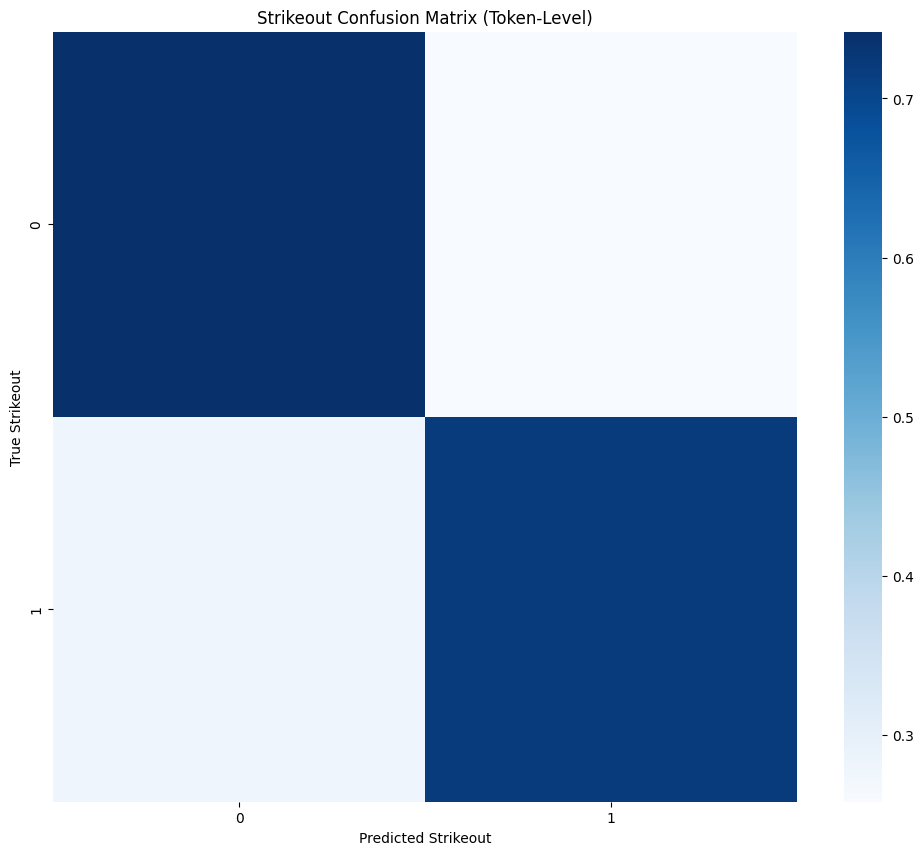

[0]	validation_0-aucpr:0.64151


c:\Users\Lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\callback.py:386: UserWarning: [18:29:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
c:\Users\Lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\callback.py:386: UserWarning: [18:29:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-aucpr:0.65902
[200]	validation_0-aucpr:0.66802
[300]	validation_0-aucpr:0.67640
[400]	validation_0-aucpr:0.68518
[500]	validation_0-aucpr:0.69272
[600]	validation_0-aucpr:0.69971
[700]	validation_0-aucpr:0.70607
[800]	validation_0-aucpr:0.71161
[900]	validation_0-aucpr:0.71711
[1000]	validation_0-aucpr:0.72197
[1100]	validation_0-aucpr:0.72651
[1200]	validation_0-aucpr:0.73121
[1300]	validation_0-aucpr:0.73568
[1400]	validation_0-aucpr:0.73987
[1500]	validation_0-aucpr:0.74376
[1600]	validation_0-aucpr:0.74749
[1700]	validation_0-aucpr:0.75102
[1800]	validation_0-aucpr:0.75417
[1900]	validation_0-aucpr:0.75720
[2000]	validation_0-aucpr:0.76016
[2100]	validation_0-aucpr:0.76309
[2200]	validation_0-aucpr:0.76601
[2300]	validation_0-aucpr:0.76899
[2400]	validation_0-aucpr:0.77137
[2500]	validation_0-aucpr:0.77359
[2600]	validation_0-aucpr:0.77603
[2700]	validation_0-aucpr:0.77816
[2800]	validation_0-aucpr:0.78041
[2900]	validation_0-aucpr:0.78247
[2999]	validation_0-auc

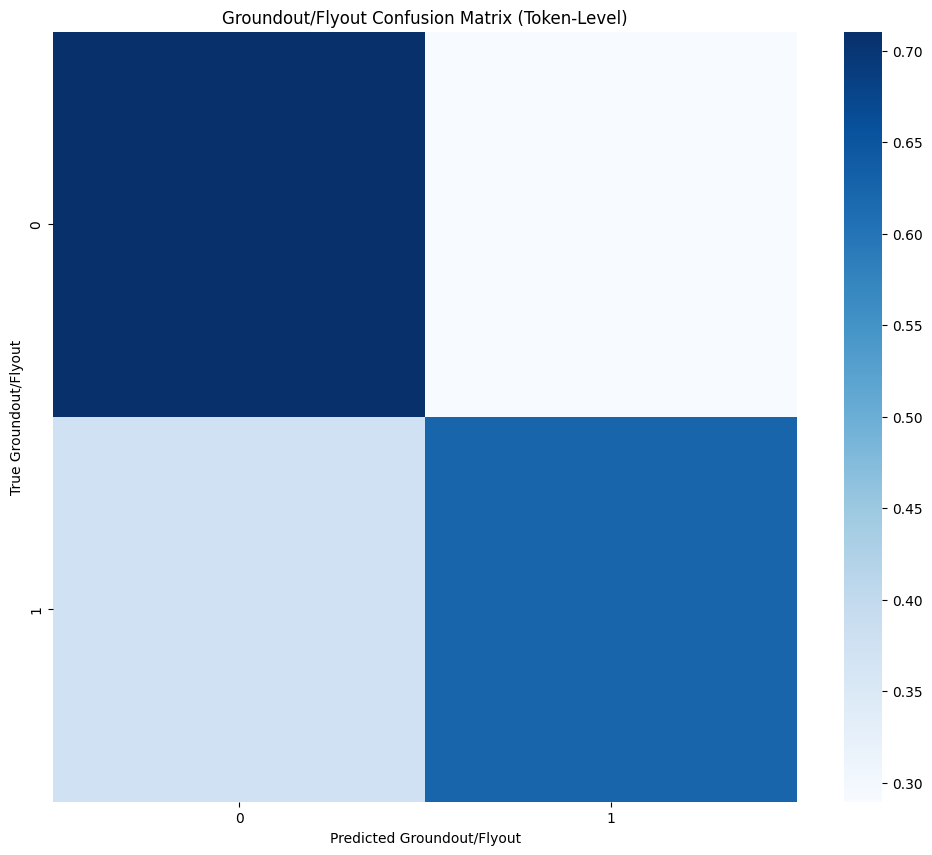

              precision    recall  f1-score   support

   strikeout       0.57      0.72      0.64     40442
   groundout       0.52      0.55      0.53     36044
      flyout       0.66      0.49      0.56     49282

    accuracy                           0.58    125768
   macro avg       0.58      0.59      0.58    125768
weighted avg       0.59      0.58      0.58    125768

[[29142  5717  5583]
 [ 9290 19739  7015]
 [12730 12472 24080]]


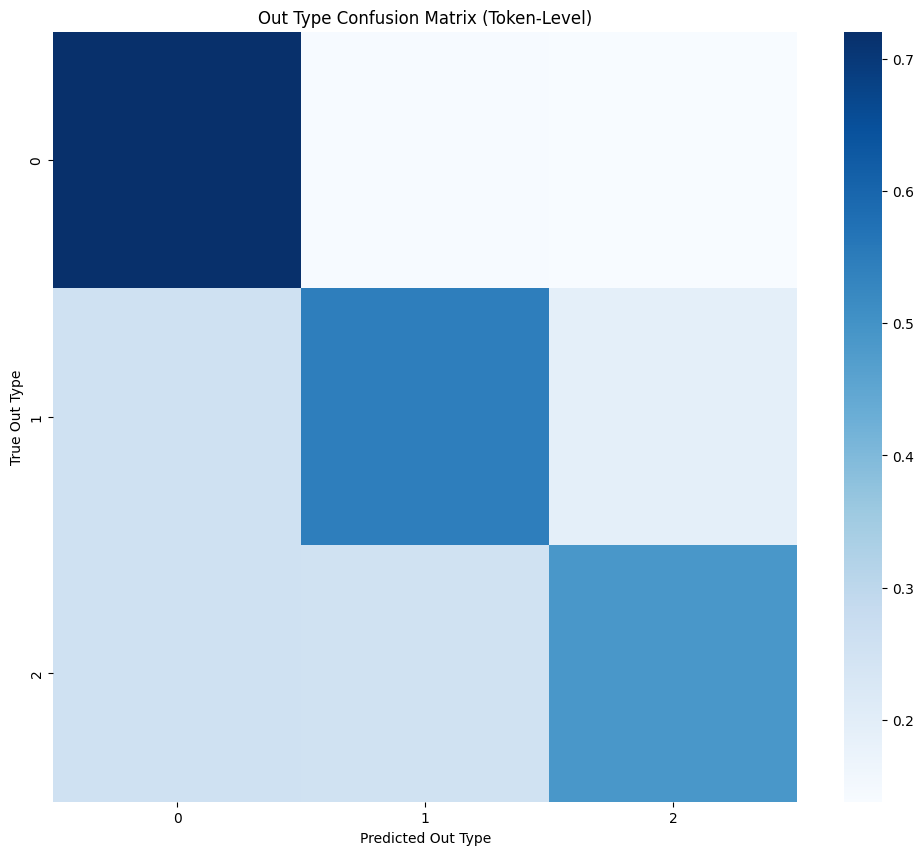

In [12]:
from matplotlib import pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve

bb_out_labels = {
    'groundout': 0,
    'flyout': 1
}

model_data['target1'] = (model_data['out_type'] == 'strikeout').astype(int)

model_data['target2'] = model_data['out_type'].map(bb_out_labels)
# model_data = model_data.dropna(subset=['target1'])
# bools = model_data.select_dtypes(include=['bool']).columns
# model_data[bools] = model_data[bools].astype(int)
model_data['strikes_x_batter_whiff'] = model_data['strikes'] * model_data['batter_rolling_whiff_rate']
model_data['strikes_x_pitcher_whiff'] = model_data['strikes'] * model_data['pitcher_rolling_whiff_rate']

# model_data['two_strikes'] = (model_data['strikes'] == 2).astype(int)
model_data['full_count'] = ((model_data['balls'] == 3) & (model_data['strikes'] == 2)).astype(int)
model_data['balls_x_batter_whiff'] = model_data['balls'] * model_data['batter_rolling_whiff_rate']
model_data['whiff_rate_diff'] = model_data['batter_rolling_whiff_rate'] - model_data['pitcher_rolling_whiff_rate']
model_data['is_platoon'] = model_data['p_throws_R'] != model_data['stand_R']
# model_data['high_intent_whiff'] = (model_data['strikes'] == 2) * model_data['batter_prev_chase_rate']


X1 = model_data.drop(columns=['target1', 'target2', 'out_type'])
y1 = model_data['target1']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

xgb_so = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=1.1,
    tree_method='hist',
    device='cuda',
    max_depth=6,
    n_estimators=3000,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42
)

xgb_so.fit(X1_train, y1_train, eval_set=[(X1_test, y1_test)], verbose=100)
# y_pred = xgb_so.predict(X1_test)

# print(classification_report(
#     y1_test,
#     y_pred,
#     target_names=['Not SO', 'SO']
# ))


y1_proba = xgb_so.predict_proba(X1_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y1_test, y1_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
so_threshold = thresholds[optimal_idx]
y1_pred_optimized = (y1_proba >= so_threshold).astype(int)


importance = pd.Series(
    xgb_so.feature_importances_,
    index=X1_train.columns
).sort_values(ascending=False)
print(importance)

print(f"Optimal threshold: {so_threshold:.3f}")
print(classification_report(y1_test, y1_pred_optimized, target_names=['Not SO', 'SO']))

cm = confusion_matrix(y1_test, y1_pred_optimized)
print(cm)


cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    fmt="d"
)
plt.xlabel("Predicted Strikeout")
plt.ylabel("True Strikeout")
plt.title("Strikeout Confusion Matrix (Token-Level)")
plt.show()



X2 = model_data[model_data['target1'] == 0].drop(columns=[
    'target1', 'target2', 'out_type', 'strikes_x_batter_whiff', 'strikes_x_pitcher_whiff', 
    'full_count', 'balls_x_batter_whiff', 'whiff_rate_diff',
    'batter_prev_whiff_rate', 'batter_rolling_whiff_rate', 'pitcher_prev_whiff_rate', 'pitcher_rolling_whiff_rate',
    'batter_prev_looking_strike_rate', 'batter_prev_zone_contact_rate', 'batter_prev_chase_rate', 'pitcher_prev_chase_rate'
]) # contact rate?
y2 = model_data[model_data['target1'] == 0]['target2']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

xgb_bb = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    device='cuda',
    scale_pos_weight=0.85,
    max_depth=5,
    n_estimators=3000,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    early_stopping_rounds=50
)

xgb_bb.fit(X2_train, y2_train, eval_set=[(X2_test, y2_test)], verbose=100)
y2_proba = xgb_bb.predict_proba(X2_test)[:, 1]
y2_pred = (y2_proba >= 0.55).astype(int)

# y2_proba = xgb_bb.predict_proba(X1_test)[:, 1]

# precisions, recalls, thresholds = precision_recall_curve(y2_test, y2_proba)
# f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
# optimal_idx = np.argmax(f1_scores)
# bip_threshold = thresholds[optimal_idx]
# y2_pred_optimized = (y2_proba >= bip_threshold).astype(int)


importance = pd.Series(
    xgb_bb.feature_importances_,
    index=X2_train.columns
).sort_values(ascending=False)

print(importance)

print(classification_report(
    y2_test,
    y2_pred,
    target_names=['GO', 'FO']
))

cm = confusion_matrix(y2_test, y2_pred)
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    fmt="d"
)
plt.xlabel("Predicted Groundout/Flyout")
plt.ylabel("True Groundout/Flyout")
plt.title("Groundout/Flyout Confusion Matrix (Token-Level)")
plt.show()



def predict_three_class_thresholded(X_full, xgb_so, xgb_bb, X2_columns, so_thresh, bip_thresh):
    p_so = xgb_so.predict_proba(X_full)[:, 1]
    
    X_for_stage2 = X_full[X2_columns]
    p_fo_given_bip = xgb_bb.predict_proba(X_for_stage2)[:, 1]
    
    final_preds = np.ones(len(X_full), dtype=int)
    
    for i in range(len(X_full)):
        if p_so[i] >= so_thresh:
            final_preds[i] = 0 
        elif p_fo_given_bip[i] >= bip_thresh:
            final_preds[i] = 2
        else:
            final_preds[i] = 1
            
    return final_preds

y_pred_combined = predict_three_class_thresholded(X1_test, xgb_so, xgb_bb, X2_train.columns, so_thresh=so_threshold, bip_thresh=0.55)

# y_pred_combined, probs = predict_three_class(X1_test, xgb_so, xgb_bb, X2_train.columns)

y_test_3class = model_data.loc[X1_test.index, 'out_type'].map({
    'strikeout': 0,
    'groundout': 1, 
    'flyout': 2
})

print(classification_report(
    y_test_3class,
    y_pred_combined,
    target_names=['strikeout', 'groundout', 'flyout']
))

cm = confusion_matrix(y_test_3class, y_pred_combined)
print(cm)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    fmt="d"
)
plt.xlabel("Predicted Out Type")
plt.ylabel("True Out Type")
plt.title("Out Type Confusion Matrix (Token-Level)")
plt.show()
